# ConvexAD (JAX): Geometrically regularized Automatic Differentiation model for BCDI phase retrieval

Author: **Matteo Masto**

Post-Doctoral fellow at CEA Grenoble and ESRF

This is the JAX port of the original TensorFlow `convex_ad` demo notebook, adapted to use the
`convexad_jax` package (https://github.com/matteomasto/convexad_jax), installed in the
`jax-pynx-env` environment alongside PyNX and cdiutils.

Main differences from the TF version, reflected below:
- A single call to `convexad_jax.reconstruct(...)` replaces the manual `model()` + training-loop
  cells: it runs `n_restarts` independent optimizations in parallel via `jax.vmap` and returns the
  best one.
- There is no `convex_ad_jax.viz` module (unlike the TF package's `convex_ad.viz`), so the plotting
  helpers are ported inline below, straight from `convex_ad/viz.py` -- they're pure NumPy/Matplotlib,
  so they work unchanged on JAX arrays once converted with `np.asarray`.
- `optimizer="adam"` is the default in this port (not L-BFGS) -- see the package README for why:
  L-BFGS was found to stall on this project's actual (non-smooth) loss.

## Check GPU is visible to JAX

In [1]:
import jax
print(jax.__version__)
print("Devices:", jax.devices())

0.6.2
Devices: [CudaDevice(id=0)]


## Imports

In [10]:
import time
import numpy as np
import jax
import jax.numpy as jnp
import scipy
from scipy.fft import fftshift, ifftshift, fftn, ifftn
import pylab as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.colors import LogNorm
import hdf5plugin
import h5py

from convexad_jax import reconstruct, fourier_loss
import pynx
import cdiutils

## Visualization utilities

Ported from `convex_ad/viz.py` (TF version). Pure NumPy/Matplotlib -- no TF/JAX dependency, so
these work identically here. Pass `np.asarray(x)` if you hand them a live JAX array.

In [3]:
def plot_3D_projections(
    data: np.ndarray,
    mask: np.ndarray = None,
    alpha_mask: float = 0.3,
    ax=None,
    fig=None,
    fw: float = 4,
    fig_title: str = None,
    axes_labels: bool = False,
    colorbar: bool = False,
    log_scale: bool = True,
    log_threshold: bool = False,
    max_projection: bool = False,
    vmin: float = None,
    vmax: float = None,
    cmap=None,
):
    """Plot 3 orthogonal projections (sum, or max if max_projection=True) of a 3D volume."""
    data = np.asarray(data)
    if cmap is None:
        cmap = "plasma"
    if fig is None:
        fig, ax = plt.subplots(1, 3, figsize=(3 * fw, fw))

    plots = []
    for n in range(3):
        proj = np.nanmax(data, axis=n) if max_projection else np.nansum(data, axis=n)
        if log_scale:
            if log_threshold:
                proj = np.log10(np.maximum(proj, 1e-12))
                im = ax[n].matshow(proj, cmap=cmap, vmin=vmin, vmax=vmax)
            else:
                im = ax[n].matshow(proj, cmap=cmap, norm=LogNorm(vmin=vmin, vmax=vmax))
        else:
            im = ax[n].matshow(proj, cmap=cmap, vmin=vmin, vmax=vmax)
        plots.append(im)

        if mask is not None:
            m = np.nanmean(np.asarray(mask), axis=n)
            m = (m != 0).astype(float)
            overlay = np.zeros((*m.shape, 4))
            overlay[..., 0] = m
            overlay[..., 3] = alpha_mask * m
            ax[n].imshow(overlay)

    if axes_labels:
        ax[0].set_xlabel("detector horizontal"); ax[0].set_ylabel("detector vertical")
        ax[1].set_xlabel("detector horizontal"); ax[1].set_ylabel("rocking curve")
        ax[2].set_xlabel("detector vertical");   ax[2].set_ylabel("rocking curve")

    if colorbar:
        for i, im in enumerate(plots):
            divider = make_axes_locatable(ax[i])
            cax = divider.append_axes("right", size="5%", pad=0.05)
            fig.colorbar(im, cax=cax)

    if fig_title:
        fig.suptitle(fig_title)
    fig.tight_layout()


def get_cropped_module_phase(
    obj: np.ndarray,
    threshold_module: float = None,
    support: np.ndarray = None,
    crop: bool = False,
    apply_fftshift: bool = False,
    unwrap: bool = True,
):
    """Extract amplitude and phase from a complex object, with optional support-based masking
    and phase unwrapping."""
    obj = np.asarray(obj)
    if apply_fftshift:
        obj = np.fft.fftshift(obj)

    module = np.abs(obj)
    if support is None:
        if threshold_module is None:
            threshold_module = 0.3
        support = module >= threshold_module * np.nanmax(module)
    else:
        support = np.asarray(support).astype(bool)

    phase = np.angle(obj)
    if unwrap:
        from skimage.restoration import unwrap_phase
        mask = ~support
        phase = np.ma.masked_array(phase, mask=mask)
        phase = unwrap_phase(phase).data

    phase = phase.copy()
    phase[~support] = np.nan
    return module, phase


def plot_2D_slices_middle_one_array3D(
    array: np.ndarray,
    index: int = None,
    voxel_sizes=None,
    add_colorbar: bool = True,
    cmap: str = "gray_r",
    norm=None,
    ax=None,
    fig=None,
    fw: float = 3,
    fig_title: str = None,
    alpha=1.0,
    vmin=None,
    vmax=None,
    aspect=None,
    symmetric_colorscale: bool = False,
):
    """Plot the three central orthogonal slices of a 3D array."""
    array = np.asarray(array)
    shape = array.shape
    if fig is None:
        fig, ax = plt.subplots(1, 3, figsize=(3 * fw, fw))

    images = []
    for n in range(3):
        s = [slice(None)] * 3
        s[n] = shape[n] // 2 if index is None else min(index, shape[n] - 1)
        arr = array[tuple(s)]

        local_vmin, local_vmax, local_cmap = vmin, vmax, cmap
        if symmetric_colorscale:
            local_vmax = np.nanmax(np.abs(arr))
            local_vmin = -local_vmax
            local_cmap = "coolwarm"

        im = ax[n].imshow(arr, cmap=local_cmap, alpha=alpha, vmin=local_vmin, vmax=local_vmax,
                           norm=norm, aspect=aspect)
        images.append(im)

    if add_colorbar:
        for i, im in enumerate(images):
            divider = make_axes_locatable(ax[i])
            cax = divider.append_axes("right", size="5%", pad=0.05)
            fig.colorbar(im, cax=cax)

    if fig_title:
        fig.suptitle(fig_title)
    fig.tight_layout()


def plot_2D_slices_middle_only_module(obj, crop=False, voxel_sizes=None, cmap="gray_r",
                                       vmin=None, vmax=None, fig_title=None):
    module, _ = get_cropped_module_phase(obj, crop=crop)
    plot_2D_slices_middle_one_array3D(module, cmap=cmap, voxel_sizes=voxel_sizes,
                                       vmin=vmin, vmax=vmax, fig_title=fig_title)


def plot_2D_slices_middle_only_phase(obj, crop=False, threshold_module=None, support=None,
                                      voxel_sizes=None, cmap="hsv", unwrap=True, fig_title=None):
    _, phase = get_cropped_module_phase(obj, threshold_module=threshold_module, support=support,
                                         crop=crop, unwrap=unwrap)
    plot_2D_slices_middle_one_array3D(phase, cmap=cmap, voxel_sizes=voxel_sizes, fig_title=fig_title)

## Load and visualize the data

Iobs shape: (128, 128, 128)


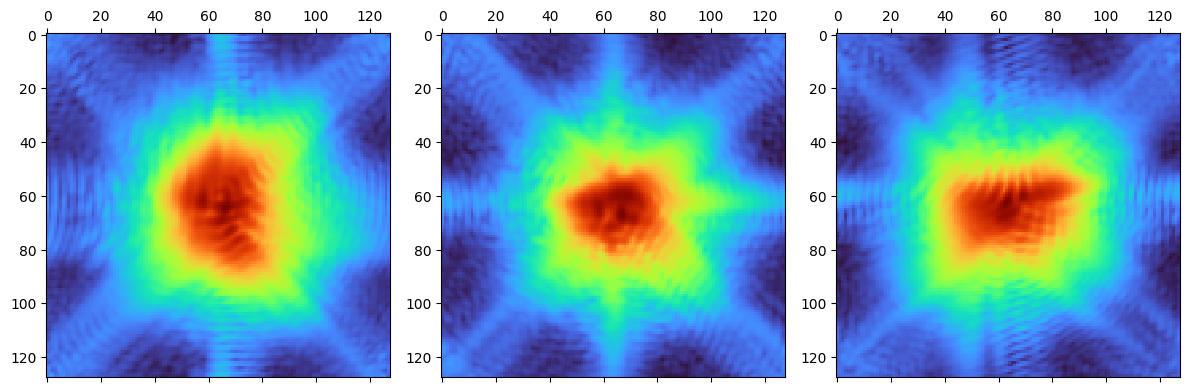

In [4]:
# path = "data_prova.npz"
path = "../../ad_github/notebooks/data_prova.npz"  # <-- set this to your .npz file
Iobs = np.load(path)["I"]
print("Iobs shape:", Iobs.shape)
plot_3D_projections(Iobs, cmap="turbo")

## Solve the phase retrieval problem

In the TF version this was a `PhaseRetrievalModel` instantiation followed by a manual training
loop over `convex_ad.train_step`, with `bs` (batch size) independent restarts stepped together
with a single optimizer. Here, `reconstruct(...)` does the equivalent (parallel restarts via
`jax.vmap`, each with its own independent optimizer state) in one call, and returns only the
best restart by final loss.

In [6]:
key = jax.random.PRNGKey(0)

t0 = time.time()
result = reconstruct(
    key,
    Iobs,
    n_restarts=16,       # TF version's "bs" (batch size / parallel restarts)
    N=64,
    size_factor=4.0,
    eps=0.6,
    alpha=0.0,            # support-size penalty weight
    beta=0.01,             # phase-TV penalty weight
    metric="mae",         # "mae" or "poisson"
    phase_type="displacement",    # "grid" | "phasor" | "displacement"
    support_type="single",
    optimizer="adam",
    max_steps=1000,
    tol=1e-6,
    learning_rate=0.05,
    grid_shape=None,      # defaults to Iobs.shape // 2, as in the TF version
)
print(f"done in {time.time() - t0:.1f}s")
print(f"best loss: {float(result.best_loss):.4f}")
print(f"all restart losses: {np.asarray(result.all_losses)}")

done in 36.3s
best loss: 0.0808
all restart losses: [0.2433302  0.22804223 0.0807662  0.24932612 0.22852442 0.2337546
 0.11577892 0.23677741 0.24105522 0.23776391 0.24311875 0.23306865
 0.24732134 0.2224157  0.21338148 0.22775982]


## Visualize the results

In [7]:
support, amplitude, phase = result.evaluate(Iobs)

support = np.asarray(support)
amplitude = np.asarray(amplitude)

# phase is either a raw array ("grid") or a (cos, sin) tuple ("phasor"/"displacement")
if isinstance(phase, tuple):
    c, s = phase
    phase = np.arctan2(np.asarray(s), np.asarray(c))
else:
    phase = np.asarray(phase)

obj = amplitude * support * np.exp(1j * phase)
print("reconstructed object shape:", obj.shape)

reconstructed object shape: (64, 64, 64)


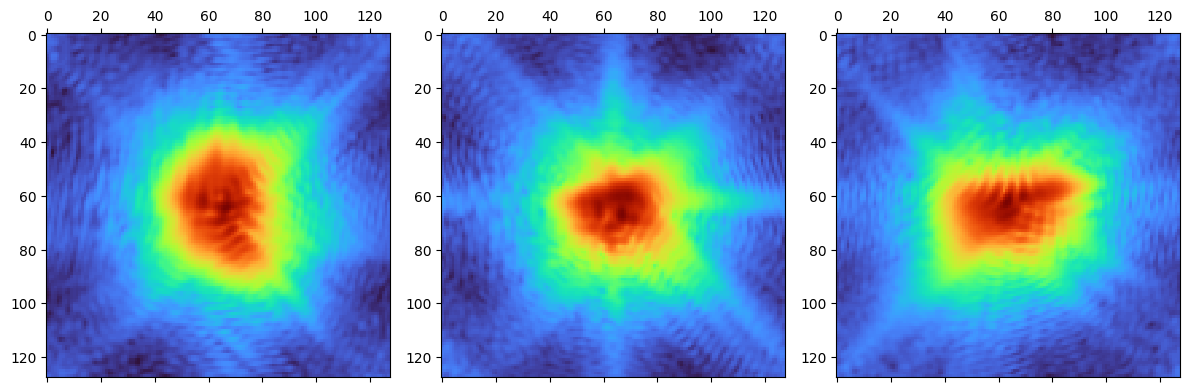

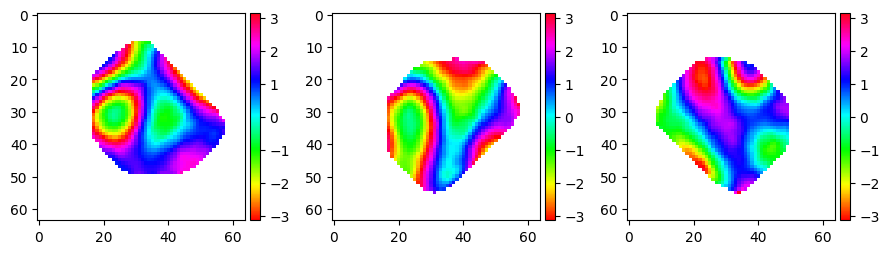

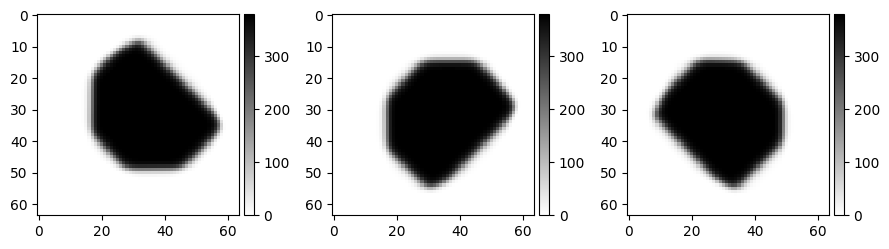

In [8]:
def _center_pad(x, target_shape):
    pads = []
    for src, dst in zip(x.shape, target_shape):
        delta = dst - src
        p0 = delta // 2
        p1 = delta - p0
        pads.append((p0, p1))
    return np.pad(x, pads)

obj_p = _center_pad(obj, Iobs.shape)

# --- FFT: |F(obj)|^2, same convention as the TF version's fft3d/fftshift/ifftshift ---
Icalc = np.abs(ifftshift(fftn(fftshift(obj_p)))) ** 2

plot_3D_projections(Icalc, log_scale=True, cmap="turbo")
plot_2D_slices_middle_only_phase(obj, cmap="hsv", unwrap=False)
plot_2D_slices_middle_only_module(obj)

## Refine the object with Iobs

Same idea as the TF demo's refinement step: keep the calculated reciprocal-space phase, but
replace the calculated magnitude with the measured `sqrt(Iobs)`, then inverse-FFT back to real
space (a single error-reduction-style projection).

In [ ]:
def project(obj_p, Iobs):
    """Replace the calculated Fourier magnitude with sqrt(Iobs), keep the calculated phase,
    and invert back to real space. Same fftshift convention as the FFT cell above."""
    F = ifftshift(fftn(fftshift(obj_p)))
    F_phase = np.angle(F)
    F_new = np.sqrt(np.maximum(Iobs, 0)) * np.exp(1j * F_phase)
    obj_new = ifftshift(ifftn(fftshift(F_new)))
    return obj_new

final_obj = project(obj_p, Iobs)
plot_2D_slices_middle_only_module(final_obj, fig_title="3D-slice_modulus")
plot_2D_slices_middle_only_phase(final_obj, fig_title="3D-slice_phase", cmap="hsv", unwrap=False)

## Ground truth object (optional)

Only runs if your `.npz` file also contains an `"obj"` array (e.g. from a simulated dataset).

In [ ]:
try:
    obj_true = np.load(path)["obj"]
    plot_2D_slices_middle_only_phase(obj_true, fig_title="ground truth phase", cmap="hsv", unwrap=False)
    plot_2D_slices_middle_only_module(obj_true, fig_title="ground truth modulus")
except KeyError:
    print("No 'obj' key in this .npz -- skipping ground-truth comparison.")

## Save results

Saves the reconstructed object and the observed data. Unlike the TF version's
"save trainable variables for further optimization" cell, `result.best_params` here is a JAX
pytree (nested dict of arrays) rather than a set of Keras variables -- convert to NumPy before
saving if you want to reload the raw half-space/phase parameters later, not just the evaluated
object.

In [ ]:
# np.savez("convexad_jax_result.npz", obj=obj_p, data=Iobs, final_obj=final_obj)

# To save the raw trainable parameters for a later warm start:
# import jax.tree_util as jtu
# params_np = jtu.tree_map(np.asarray, result.best_params)
# np.savez("convexad_jax_params.npz", **{k: v for k, v in params_np.items() if not isinstance(v, dict)})